In [1]:
import os
import sys

sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import open_clip
import torch
import faiss

from utils.embedding import *
from utils.retrieval import *

c:\Users\kanishkas\AppData\Local\anaconda3\envs\lace_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
catalogue = get_catalogue_images("../catalogue")
print(f"Total catalogue images: {len(catalogue)}")

Total catalogue images: 89


In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model, _, preprocess = open_clip.create_model_and_transforms(
    "hf-hub:Marqo/marqo-fashionSigLIP"
)

model = model.to(device)
model.eval()

print("FashionSigLIP loaded successfully!")

FashionSigLIP loaded successfully!


In [4]:
catalogue_embeddings = np.load("../embeddings/catalogue_embeddings.npy")
catalogue = np.load("../embeddings/catalogue_paths.npy", allow_pickle=True)

print(catalogue_embeddings.shape)
print(len(catalogue))

(89, 768)
89


In [5]:
faiss.normalize_L2(catalogue_embeddings)

print("Embeddings normalized successfully!")

Embeddings normalized successfully!


In [6]:
index = build_faiss_index(catalogue_embeddings)

print("FAISS Index Created!")
print("Total vectors:", index.ntotal)

FAISS Index Created!
Total vectors: 89


In [7]:
query_image = "../query_images/LACE1007_0.jpeg"

In [8]:
import importlib
import utils.retrieval

importlib.reload(utils.retrieval)

from utils.retrieval import *

In [9]:
scores, results = search(
    query_image_path=query_image,
    index=index,
    catalogue=catalogue,
    model=model,
    preprocess=preprocess,
    device=device,
    top_k=5
)

In [10]:
print("Top 5 Results\n")

for score, image_path in zip(scores[0], results):
    print(f"{score:.4f}")
    print(image_path)
    print("-" * 40)

Top 5 Results

1.0000
../catalogue/LACE1007\LACE1007_0.jpeg
----------------------------------------
0.9541
../catalogue/LACE1020\LACE1020_0.jpeg
----------------------------------------
0.9506
../catalogue/LACE1015\LACE1015_0.jpeg
----------------------------------------
0.9468
../catalogue/LACE1024\LACE1024_0.jpeg
----------------------------------------
0.9419
../catalogue/TESTIMG0019\source-021.jpeg
----------------------------------------


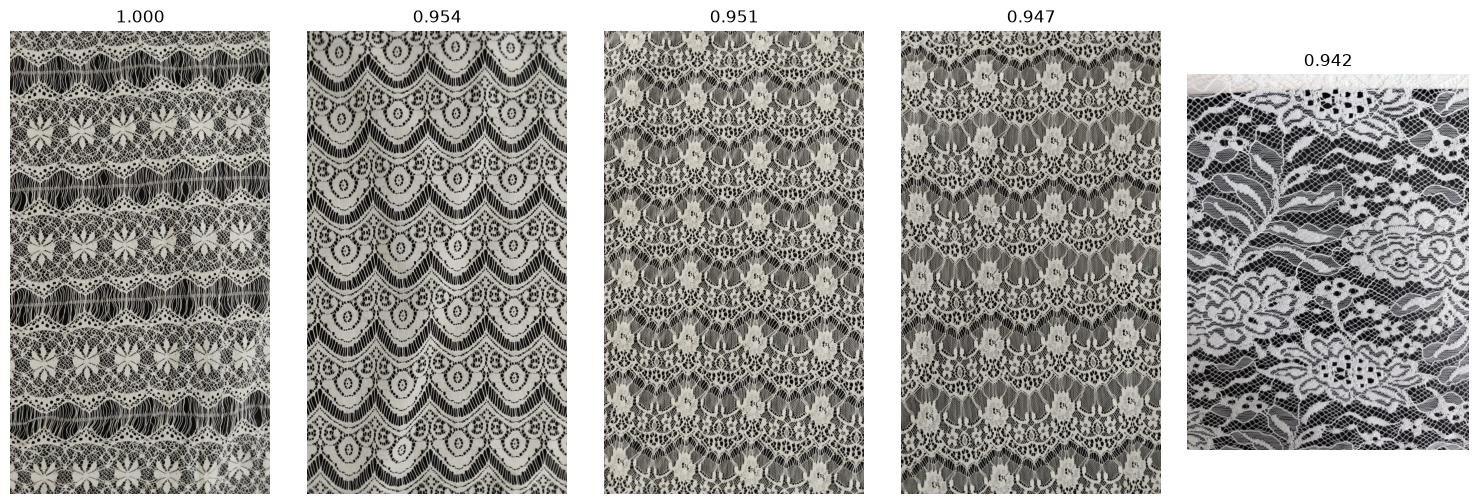

In [11]:
plt.figure(figsize=(15, 5))

for i, image_path in enumerate(results):

    image = load_image(image_path)

    plt.subplot(1, len(results), i + 1)

    plt.imshow(image)

    plt.title(f"{scores[0][i]:.3f}")

    plt.axis("off")

plt.tight_layout()
plt.show()